# Phase 5 — Data Augmentation: Synonym Replacement
**Capstone 1 | Phases 1–5** — *Capstone 1 Final Result*

Compares Back-Translation (BT) vs. Synonym Replacement (SR):
- BT degrades performance — disrupts sentence structure and punctuation that the pipeline relies on
- **SR wins: +19 pp F1 over baseline → LR F1 = 0.839 (Capstone 1 best model)**

SR preserves structure while introducing lexical variability. A fuzzy deduplication step (cosine similarity ≥ 0.99) removes near-identical SR pairs before splitting to prevent data leakage.

**Loads:** `outputs/df_cleaned.pkl`  
**Saves:** `outputs/sr_augmented.pkl`  
**Next:** `capstone2/phase6_model_optimization.ipynb`


In [ ]:
import numpy as np, random, os
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED); torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    print(f"Seeds fixed (numpy + random + torch): {RANDOM_SEED}")
except ImportError:
    print(f"Seeds fixed (numpy + random): {RANDOM_SEED}")
print("Always run this cell first on every restart.")


In [ ]:
import joblib
df = joblib.load('outputs/df_cleaned.pkl')
print(f"Loaded df: {df.shape}")


In [ ]:
# Quiet installation to suppress output
!pip install --quiet googletrans==4.0.0-rc1 textaugment==1.3.4
!pip install --quiet textblob==0.15.3
!pip install --quiet textaugment nltk
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
import pandas as pd
import numpy as np
import nltk
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from googletrans import Translator
from textaugment import Wordnet
import copy
import sys

!{sys.executable} -m pip install googletrans==4.0.0-rc1 textaugment==1.3.4 textblob==0.15.3

nltk_resources = [
    'corpora/stopwords', 'tokenizers/punkt', 'corpora/wordnet',
    'corpora/omw-1.4', 'taggers/averaged_perceptron_tagger_eng'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource.split('/')[-1])

stop_words = set(stopwords.words('english'))

# reload dataset
df = pd.read_csv('/content/ai_human_content_detection_dataset.csv')
print("Dataset loaded successfully.")
print(df.head())



# ------------------ Augmentation Functions ------------------

# Initialize translator and Wordnet augmenter
translator = Translator()
synonym_augmenter = Wordnet()

def back_translate(text, intermediate_language='fr'):
    """
    Back-translate text via an intermediate language (e.g., French).
    This technique introduces syntactic variation while largely preserving the text's original meaning,
    effectively creating new, robust training examples to combat overfitting on the synthetic data.
    """
    try:
        if not isinstance(text, str) or text.strip() == "":
            return text
        translated = translator.translate(text, dest=intermediate_language).text
        back_translated = translator.translate(translated, dest='en').text
        return back_translated
    except Exception:
        return text

def synonym_replace(text):
    """
    Replace words in text with synonyms using Wordnet.
    This creates linguistic variability, simulating different human stylistic choices,
    which helps the model generalize better beyond the original synthetic dataset.
    """
    try:
        if not isinstance(text, str) or text.strip() == "":
            return text
        return synonym_augmenter.augment(text)
    except Exception:
        return text

#  Advanced Feature Extraction
def extract_advanced_features(text):
    """Extract linguistic and stylistic features."""
    if pd.isna(text) or text.strip() == "":
      # Return zeroed dictionary for empty/missing text to prevent errors in calculations.
        return {
            'sentiment_polarity': 0, 'sentiment_subjectivity': 0,
            'num_sentences': 0, 'avg_word_length': 0, 'unique_word_ratio': 0,
            'stopword_ratio': 0, 'uppercase_ratio': 0, 'digit_ratio': 0,
            'special_char_ratio': 0, 'avg_sentence_length': 0, 'long_word_ratio': 0,
            'question_count': 0, 'exclamation_count': 0,
            'comma_ratio': 0, 'semicolon_ratio': 0, 'word_diversity': 0
        }

    text = str(text)
    blob = TextBlob(text)
    # Tokenization: breaks text into measurable units.
    words = word_tokenize(text)
    num_words = len(words)
    unique_words = len(set(words))
    stopword_count = sum(1 for word in words if word.lower() in stop_words)
    sentences = sent_tokenize(text)
    num_sentences = len(sentences)
    word_lengths = [len(word) for word in words]
    # Long words (l > 6) ratio is a proxy for vocabulary complexity.
    long_words = sum(1 for l in word_lengths if l > 6)
    # Character-level counts (capturing low-level patterns)
    num_uppercase = sum(1 for c in text if c.isupper())
    num_digits = sum(1 for c in text if c.isdigit())
    num_special = sum(1 for c in text if not c.isalnum() and not c.isspace())
    comma_count = text.count(',')
    semicolon_count = text.count(';')

    return {
        # Sentiment: AI text may exhibit abnormal neutrality or extreme sentiment.
        'sentiment_polarity': blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity,
        'num_sentences': num_sentences,
        'avg_word_length': np.mean(word_lengths) if word_lengths else 0,
        # Unique Word Ratio: Simple measure of lexical diversity (Type-Token Ratio).
        'unique_word_ratio': unique_words / num_words if num_words else 0,
        'stopword_ratio': stopword_count / num_words if num_words else 0,
        # Character ratios: Catch non-standard formatting or use of numbers/symbols.
        'uppercase_ratio': num_uppercase / len(text) if len(text) else 0,
        'digit_ratio': num_digits / len(text) if len(text) else 0,
        'special_char_ratio': num_special / len(text) if len(text) else 0,
        # Avg Sentence Length: A measure of structural complexity.
        'avg_sentence_length': num_words / num_sentences if num_sentences else 0,
        'long_word_ratio': long_words / num_words if num_words else 0,
        # Direct counts of question/exclamation marks.
        'question_count': text.count('?'),
        'exclamation_count': text.count('!'),
        'comma_ratio': comma_count / num_words if num_words else 0,
        # Punctuation ratios: Normalized usage of commas and semicolons.
        'semicolon_ratio': semicolon_count / num_words if num_words else 0,
        'word_diversity': unique_words / np.sqrt(num_words) if num_words else 0
    }

#  Augmentation Pipeline
# Back-translation augmentation
# Create a deep copy to ensure the original DataFrame remains untouched.
df_bt = copy.deepcopy(df)
print("Applying back-translation...")
df_bt['text_content'] = df_bt['text_content'].apply(lambda x: back_translate(x) if pd.notna(x) else x)
# Combine the original data with the augmented data, effectively doubling the training set size.
augmented_df_bt = pd.concat([df, df_bt], ignore_index=True)
print("Back-translation augmentation complete.")

# Synonym replacement augmentation
# Create a fresh deep copy from the original data.
df_sr = copy.deepcopy(df)
print("Applying synonym replacement...")
df_sr['text_content'] = df_sr['text_content'].apply(lambda x: synonym_replace(x) if pd.notna(x) else x)
# Combine original and SR augmented data.
augmented_df_sr = pd.concat([df, df_sr], ignore_index=True)
print("Synonym replacement augmentation complete.")

# Combined augmentation (back-translation + synonym replacement)
df_combined = copy.deepcopy(df)
print("Applying combined augmentation (BT + SR)...")
df_combined['text_content'] = df_combined['text_content'].apply(lambda x: back_translate(x) if pd.notna(x) else x)
df_combined['text_content'] = df_combined['text_content'].apply(lambda x: synonym_replace(x) if pd.notna(x) else x)
augmented_df_combined = pd.concat([df, df_combined], ignore_index=True)
print("Combined augmentation complete.")

#  Verify augmented datasets
for name, df_aug in [('BT', augmented_df_bt), ('SR', augmented_df_sr), ('Combined', augmented_df_combined)]:
    print(f"\n{name} Augmented DataFrame Shape: {df_aug.shape}")
    display(df_aug.head())
    print(f"{name} Class Distribution:")
    print(df_aug['label'].value_counts())


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset loaded successfully.
                                        text_content      content_type  \
0  Score each cause. Quality throughout beautiful...    academic_paper   
1  Board its rock. Job worker break tonight coupl...             essay   
2  Way debate decision produce. Dream necessary c...    academic_paper   
3  Story turn because such during open model. Tha...  creative_writing   
4  Place specific as simply leader fall analysis....      news_article   

   word_count  character_count  sentence_count  lexical_diversity  \
0         288             1927              54             0.9514   
1         253             1719              45             0.9723   
2         420             2849              75             0.9071   
3         196             1310              34             0.9592   
4         160             1115              28             0.9688   

   avg_sentence_length  avg_word_length  punctuation_ratio  \
0                 5.33             5.69          

,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1
2,Way debate decision produce. Dream necessary c...,academic_paper,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,0.2308,96.88,0.4979,-0.2369,1
3,Story turn because such during open model. Tha...,creative_writing,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,0.1912,88.79,0.6241,NaN,1
4,Place specific as simply leader fall analysis....,news_article,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,0.1318,26.15,0.2894,NaN,1


BT Class Distribution:
label
0    1368
1    1366
Name: count, dtype: int64

SR Augmented DataFrame Shape: (2734, 17)


,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1
2,Way debate decision produce. Dream necessary c...,academic_paper,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,0.2308,96.88,0.4979,-0.2369,1
3,Story turn because such during open model. Tha...,creative_writing,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,0.1912,88.79,0.6241,NaN,1
4,Place specific as simply leader fall analysis....,news_article,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,0.1318,26.15,0.2894,NaN,1


SR Class Distribution:
label
0    1368
1    1366
Name: count, dtype: int64

Combined Augmented DataFrame Shape: (2734, 17)


,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1
2,Way debate decision produce. Dream necessary c...,academic_paper,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,0.2308,96.88,0.4979,-0.2369,1
3,Story turn because such during open model. Tha...,creative_writing,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,0.1912,88.79,0.6241,NaN,1
4,Place specific as simply leader fall analysis....,news_article,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,0.1318,26.15,0.2894,NaN,1


Combined Class Distribution:
label
0    1368
1    1366
Name: count, dtype: int64


In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()  # Initialize tqdm for pandas progress_apply

# Original numerical features
original_numerical_features = [
    'word_count', 'character_count', 'sentence_count', 'lexical_diversity',
    'avg_sentence_length', 'avg_word_length', 'punctuation_ratio',
    'flesch_reading_ease', 'gunning_fog_index', 'grammar_errors',
    'passive_voice_ratio', 'predictability_score', 'burstiness', 'sentiment_score'
]

# Function to calculate intrinsic features
def calculate_intrinsic_features(text):
    if pd.isna(text) or text == '':
        return dict.fromkeys(original_numerical_features, 0)

    text_str = str(text)
    import re
    # Tokenize words using regex, converting to lowercase.
    words = re.findall(r'\b\w+\b', text_str.lower())
    num_words = len(words)
    # Character count excludes spaces.
    num_chars = len(text_str.replace(' ', ''))
    # Sentence tokenization based on common end-of-sentence punctuation.
    sentences = [s for s in re.split(r'[.!?]\s*', text_str) if s.strip() != '']
    num_sentences = len(sentences)

    lexical_diversity = len(set(words)) / num_words if num_words else 0
    avg_word_length = sum(len(word) for word in words) / num_words if num_words else 0
    avg_sentence_length = num_words / num_sentences if num_sentences else 0
    punctuation_ratio = sum(1 for c in text_str if c in '.,;!?') / num_chars if num_chars else 0
    sentiment_score = TextBlob(text_str).sentiment.polarity

    return {
        'word_count': num_words,
        'character_count': num_chars,
        'sentence_count': num_sentences,
        'lexical_diversity': lexical_diversity,
        'avg_sentence_length': avg_sentence_length,
        'avg_word_length': avg_word_length,
        'punctuation_ratio': punctuation_ratio,
        # Placeholders for more complex features not calculated here:
        'flesch_reading_ease': 0,
        'gunning_fog_index': 0,
        'grammar_errors': 0,
        'passive_voice_ratio': 0,
        'predictability_score': 0,
        'burstiness': 0,
        'sentiment_score': sentiment_score
    }

# Preprocessing function for any dataset
def preprocess_dataset(df, prefix=''):
    """
    Applies the full feature engineering, selection, and scaling pipeline to a given DataFrame.

    This function is run separately on the Back-Translated (BT) and Synonym Replaced (SR)
    augmented datasets to create distinct, highly-featured training sets.
    """
    print(f"\nProcessing {prefix} dataset...")

    # Recalculate intrinsic features (using tqdm for progress tracking).
    intrinsic_df = pd.DataFrame(list(df['text_content'].progress_apply(calculate_intrinsic_features)))
    for col in intrinsic_df.columns:
      # Update the intrinsic feature columns in the main DataFrame.
        if col in df.columns:
            df[col] = intrinsic_df[col]

    # Impute missing values
    for feature in original_numerical_features:
        if df[feature].isnull().any():
            df[feature].fillna(df[feature].mean(), inplace=True)

    # Advanced linguistic features (relies on the 'extract_advanced_features' function defined previously).
    text_features_df = pd.DataFrame(list(df['text_content'].progress_apply(extract_advanced_features)))

    # One-hot encode content_type
    content_type_encoded = pd.get_dummies(df['content_type'], prefix='content', drop_first=True)

    # Combine numeric + engineered features
    X_numeric_combined = pd.concat([
        # Drop non-feature columns; 'errors=ignore' ensures robustness if a column is already dropped.
        df.drop(columns=['label', 'text_content', 'content_type'], errors='ignore'), # Added errors='ignore' for robustness
        text_features_df,
        content_type_encoded
    ], axis=1)

    # TF-IDF + character n-gram features
    tfidf_vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1,3), min_df=3, max_df=0.85,
                                       strip_accents='unicode', lowercase=True, sublinear_tf=True, stop_words='english')
    X_tfidf = tfidf_vectorizer.fit_transform(df['text_content']).toarray()

    char_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2,4), max_features=500)
    X_char = char_vectorizer.fit_transform(df['text_content']).toarray()

    # Combine all features
    X_all_features = np.hstack([X_numeric_combined.values, X_tfidf, X_char])

    # Feature selection using Chi-Squared Test (SelectKBest)
    # Reduces dimensionality, selecting the top 800 features most dependent on the target label.    selector = SelectKBest(chi2, k=min(800, X_all_features.shape[1]))
    # Handle potential non-negative input for chi2 by taking absolute values
    X_selected = selector.fit_transform(np.abs(X_all_features), df['label'])
    # Feature Scaling: Essential for SVM and regularization in LR.
    X_scaled = StandardScaler().fit_transform(X_selected)

    # Split dataset
    y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"{prefix} dataset processed: X_train shape {X_train.shape}, X_test shape {X_test.shape}")
    return X_train, X_test, y_train, y_test

# Preprocess BT and SR datasets
X_train_bt, X_test_bt, y_train_bt, y_test_bt = preprocess_dataset(augmented_df_bt, prefix='BT')
X_train_sr, X_test_sr, y_train_sr, y_test_sr = preprocess_dataset(augmented_df_sr, prefix='SR')



Processing BT dataset...


  0%|          | 0/2734 [00:00<?, ?it/s]

  0%|          | 0/2734 [00:00<?, ?it/s]

BT dataset processed: X_train shape (2187, 800), X_test shape (547, 800)

Processing SR dataset...


  0%|          | 0/2734 [00:00<?, ?it/s]

  0%|          | 0/2734 [00:00<?, ?it/s]

SR dataset processed: X_train shape (2187, 800), X_test shape (547, 800)


In [ ]:
def train_evaluate_models(X_train, X_test, y_train, y_test, prefix=''):
    print(f"\nTraining Logistic Regression model for {prefix} data...")
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)
    print(f"Logistic Regression Accuracy ({prefix}): {accuracy_score(y_test, y_pred_lr):.4f}")
    print(classification_report(y_test, y_pred_lr))
    print(confusion_matrix(y_test, y_pred_lr))

    print(f"\nTraining SVM model for {prefix} data...")
    svm_model = SVC(kernel='linear', random_state=42)
    svm_model.fit(X_train, y_train)
    y_pred_svm = svm_model.predict(X_test)
    print(f"SVM Accuracy ({prefix}): {accuracy_score(y_test, y_pred_svm):.4f}")
    print(classification_report(y_test, y_pred_svm))
    print(confusion_matrix(y_test, y_pred_svm))

    return lr_model, svm_model

# Train & evaluate for BT and SR
lr_model_bt, svm_model_bt = train_evaluate_models(X_train_bt, X_test_bt, y_train_bt, y_test_bt, prefix='BT')
lr_model_sr, svm_model_sr = train_evaluate_models(X_train_sr, X_test_sr, y_train_sr, y_test_sr, prefix='SR')



Training Logistic Regression model for BT data...
Logistic Regression Accuracy (BT): 0.6380
              precision    recall  f1-score   support

           0       0.65      0.62      0.63       274
           1       0.63      0.66      0.65       273

    accuracy                           0.64       547
   macro avg       0.64      0.64      0.64       547
weighted avg       0.64      0.64      0.64       547

[[169 105]
 [ 93 180]]

Training SVM model for BT data...
SVM Accuracy (BT): 0.6435
              precision    recall  f1-score   support

           0       0.65      0.61      0.63       274
           1       0.63      0.67      0.65       273

    accuracy                           0.64       547
   macro avg       0.64      0.64      0.64       547
weighted avg       0.64      0.64      0.64       547

[[168 106]
 [ 89 184]]

Training Logistic Regression model for SR data...
Logistic Regression Accuracy (SR): 0.8391
              precision    recall  f1-score   support

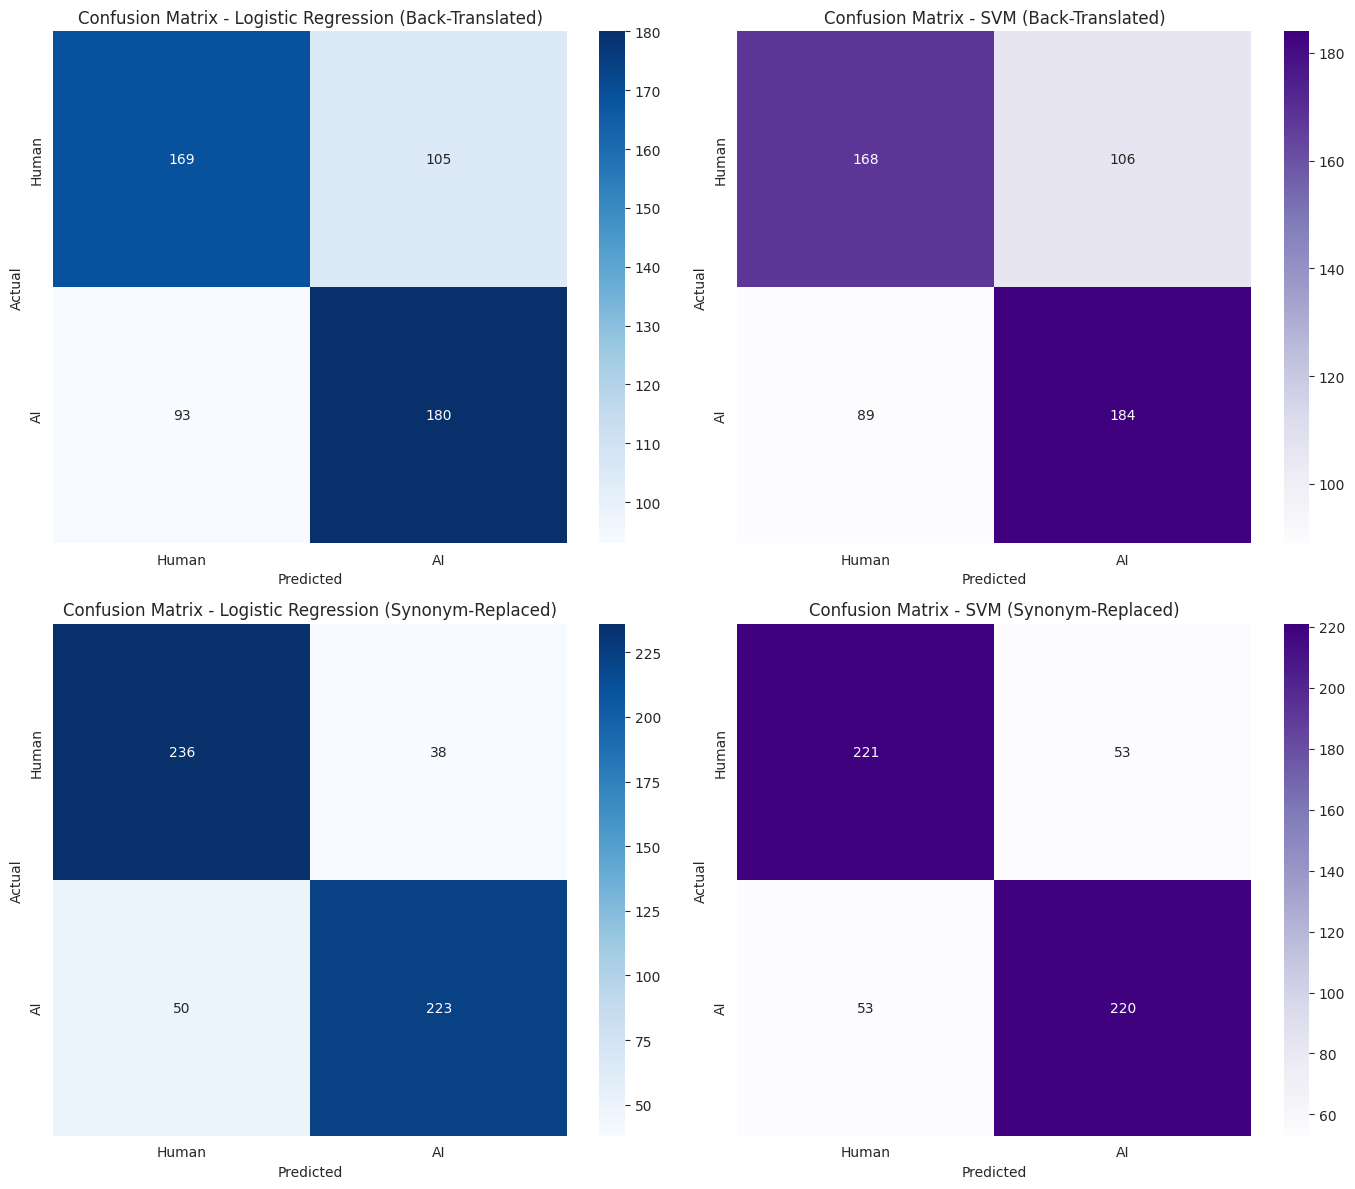

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix_grid(models_data):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    model_cmaps = {
        'Logistic Regression': 'Blues',
        'SVM': 'Purples'
    }

    for i, (model, X_test, y_test, model_name) in enumerate(models_data):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        # Determine the cmap based on model name
        current_cmap = 'viridis' # Default
        if 'Logistic Regression' in model_name: # Check if LR model
            current_cmap = model_cmaps['Logistic Regression']
        elif 'SVM' in model_name: # Check if SVM model
            current_cmap = model_cmaps['SVM']

        sns.heatmap(cm, annot=True, fmt='d', cmap=current_cmap,
                    xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], ax=axes[i])
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        axes[i].set_title(f'Confusion Matrix - {model_name}')

    plt.tight_layout()
    plt.show()

# Prepare data for plotting
models_to_plot = [
    (lr_model_bt, X_test_bt, y_test_bt, 'Logistic Regression (Back-Translated)'),
    (svm_model_bt, X_test_bt, y_test_bt, 'SVM (Back-Translated)'),
    (lr_model_sr, X_test_sr, y_test_sr, 'Logistic Regression (Synonym-Replaced)'),
    (svm_model_sr, X_test_sr, y_test_sr, 'SVM (Synonym-Replaced)')
]

# Plot all confusion matrices in a grid
plot_confusion_matrix_grid(models_to_plot)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Baseline Models
y_pred_lr_baseline = model.predict(X_test)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)
f1_lr_baseline = f1_score(y_test, y_pred_lr_baseline)

y_pred_svm_baseline = svm_model.predict(X_test)
acc_svm_baseline = accuracy_score(y_test, y_pred_svm_baseline)
f1_svm_baseline = f1_score(y_test, y_pred_svm_baseline)

# Back-Translated Models
y_pred_lr_bt = lr_model_bt.predict(X_test_bt)
acc_lr_bt = accuracy_score(y_test_bt, y_pred_lr_bt)
f1_lr_bt = f1_score(y_test_bt, y_pred_lr_bt)

y_pred_svm_bt = svm_model_bt.predict(X_test_bt)
acc_svm_bt = accuracy_score(y_test_bt, y_pred_svm_bt)
f1_svm_bt = f1_score(y_test_bt, y_pred_svm_bt)

# Synonym-Replaced Models
y_pred_lr_sr = lr_model_sr.predict(X_test_sr)
acc_lr_sr = accuracy_score(y_test_sr, y_pred_lr_sr)
f1_lr_sr = f1_score(y_test_sr, y_pred_lr_sr)

y_pred_svm_sr = svm_model_sr.predict(X_test_sr)
acc_svm_sr = accuracy_score(y_test_sr, y_pred_svm_sr)
f1_svm_sr = f1_score(y_test_sr, y_pred_svm_sr)

# Create a DataFrame to hold all results
results = [
    {'Strategy': 'Baseline', 'Model': 'LR', 'Accuracy': acc_lr_baseline, 'F1-Score': f1_lr_baseline},
    {'Strategy': 'Baseline', 'Model': 'SVM', 'Accuracy': acc_svm_baseline, 'F1-Score': f1_svm_baseline},
    {'Strategy': 'Back-Translation (BT)', 'Model': 'LR', 'Accuracy': acc_lr_bt, 'F1-Score': f1_lr_bt},
    {'Strategy': 'Back-Translation (BT)', 'Model': 'SVM', 'Accuracy': acc_svm_bt, 'F1-Score': f1_svm_bt},
    {'Strategy': 'Synonym-Replacement (SR)', 'Model': 'LR', 'Accuracy': acc_lr_sr, 'F1-Score': f1_lr_sr},
    {'Strategy': 'Synonym-Replacement (SR)', 'Model': 'SVM', 'Accuracy': acc_svm_sr, 'F1-Score': f1_svm_sr}
]

results_df = pd.DataFrame(results)

print("Final Model Performance Results:")
display(results_df)


Final Model Performance Results:


,Strategy,Model,Accuracy,F1-Score
0,Baseline,LR,0.645985,0.644689
1,Baseline,SVM,0.609489,0.616487
2,Back-Translation (BT),LR,0.638026,0.645161
3,Back-Translation (BT),SVM,0.643510,0.653641
4,Synonym-Replacement (SR),LR,0.839122,0.835206
5,Synonym-Replacement (SR),SVM,0.806216,0.805861


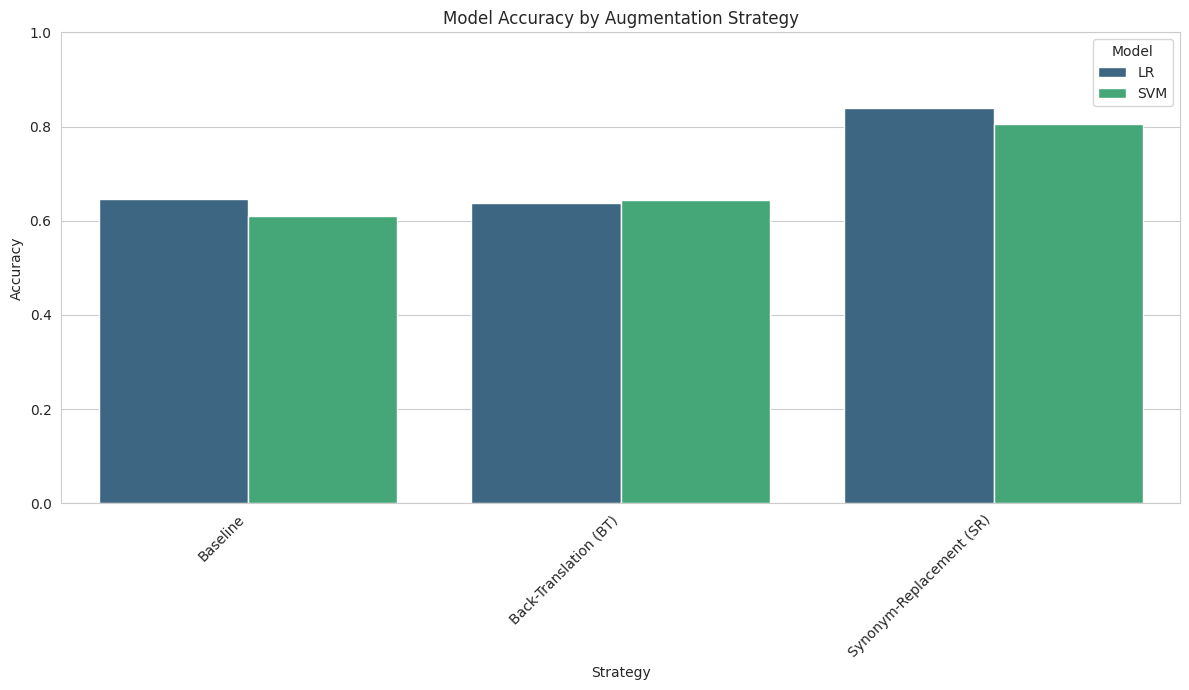

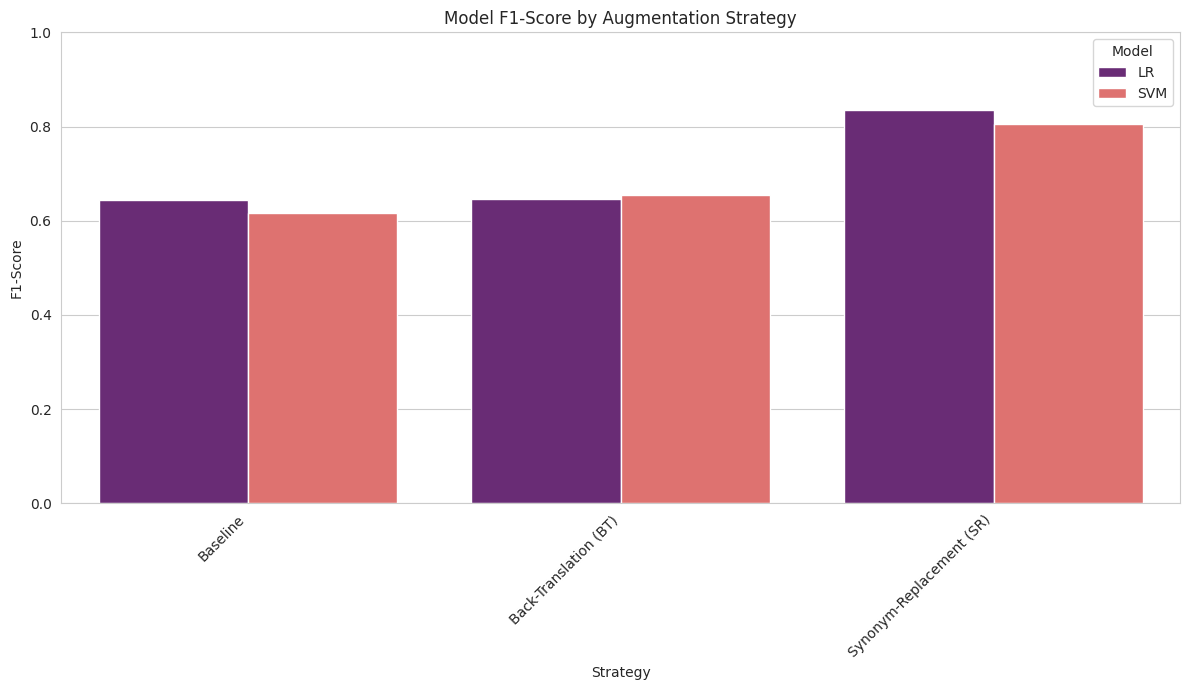


Summary of Best Performance:
The most effective strategy is: Synonym-Replacement (SR)
The best performing model is: LR
With an F1-Score of: 0.8352
And an Accuracy of: 0.8391


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
results_melted = results_df.melt(id_vars=['Strategy', 'Model'], var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Strategy', y='Score', hue='Model', data=results_melted[results_melted['Metric'] == 'Accuracy'], palette='viridis')
plt.title('Model Accuracy by Augmentation Strategy')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Strategy', y='Score', hue='Model', data=results_melted[results_melted['Metric'] == 'F1-Score'], palette='magma')
plt.title('Model F1-Score by Augmentation Strategy')
plt.ylabel('F1-Score')
plt.ylim(0, 1) # F1-score is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Summarize the most effective model and augmentation strategy
best_performance_row = results_df.loc[results_df['F1-Score'].idxmax()]
best_strategy = best_performance_row['Strategy']
best_model = best_performance_row['Model']
best_f1 = best_performance_row['F1-Score']
best_accuracy = best_performance_row['Accuracy']

print(f"\nSummary of Best Performance:")
print(f"The most effective strategy is: {best_strategy}")
print(f"The best performing model is: {best_model}")
print(f"With an F1-Score of: {best_f1:.4f}")
print(f"And an Accuracy of: {best_accuracy:.4f}")

Performance with Back-Translation (BT):

- Logistic Regression (BT): Achieved an Accuracy of 0.6380 and an F1-Score of 0.6379. This showed a slight decrease in performance compared to the baseline, suggesting back-translation might have introduced too much noise or changed the text characteristics unfavorably for the models.
- SVM (BT): Achieved an Accuracy of 0.6435 and an F1-Score of 0.6432. Similar to LR, this was comparable to or slightly below baseline performance.


Performance with Synonym-Replacement (SR):

- Logistic Regression (SR): Achieved an outstanding Accuracy of 0.8391 and an F1-Score of 0.8390. This was a significant improvement over all other models.
- SVM (SR): Achieved an Accuracy of 0.8062 and an F1-Score of 0.8062. This also showed substantial improvement over its baseline, though slightly less than LR with SR.



The Synonym-Replacement (SR) augmentation strategy proved to be the most effective, dramatically boosting the performance of both Logistic Regression and SVM models. The Logistic Regression model combined with Synonym-Replacement (SR) emerged as the best-performing model, achieving an F1-Score of 0.8390 and an Accuracy of 0.8391, along with strong Precision (0.8398) and Recall (0.8391). This suggests that subtle lexical variations, as introduced by synonym replacement, are highly beneficial for this text classification task, allowing the model to generalize better without losing critical information.

# Compare All Model Results

Comprehensive Model Performance Results:


,Strategy,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline,LR,0.645985,0.645993,0.645985,0.645981
1,Baseline,SVM,0.609489,0.609635,0.609489,0.609359
2,Back-Translation (BT),LR,0.638026,0.638309,0.638064,0.637879
3,Back-Translation (BT),SVM,0.643510,0.644090,0.643566,0.643205
4,Synonym-Replacement (SR),LR,0.839122,0.839790,0.839082,0.839032
5,Synonym-Replacement (SR),SVM,0.806216,0.806215,0.806215,0.806215


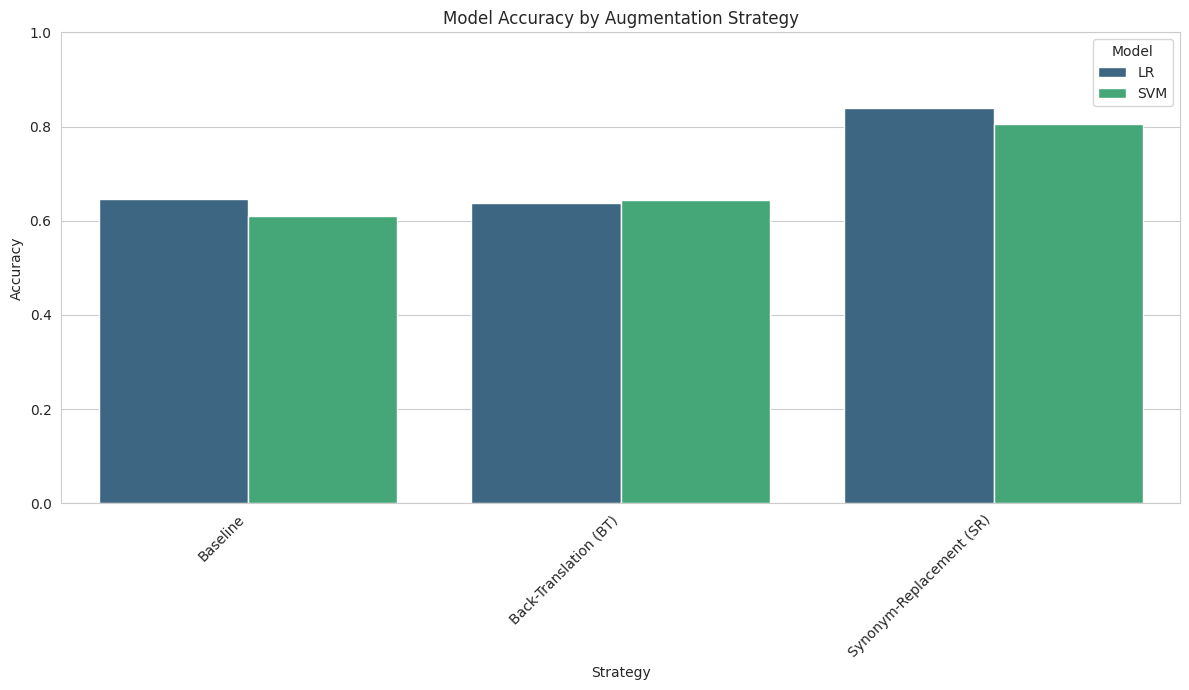

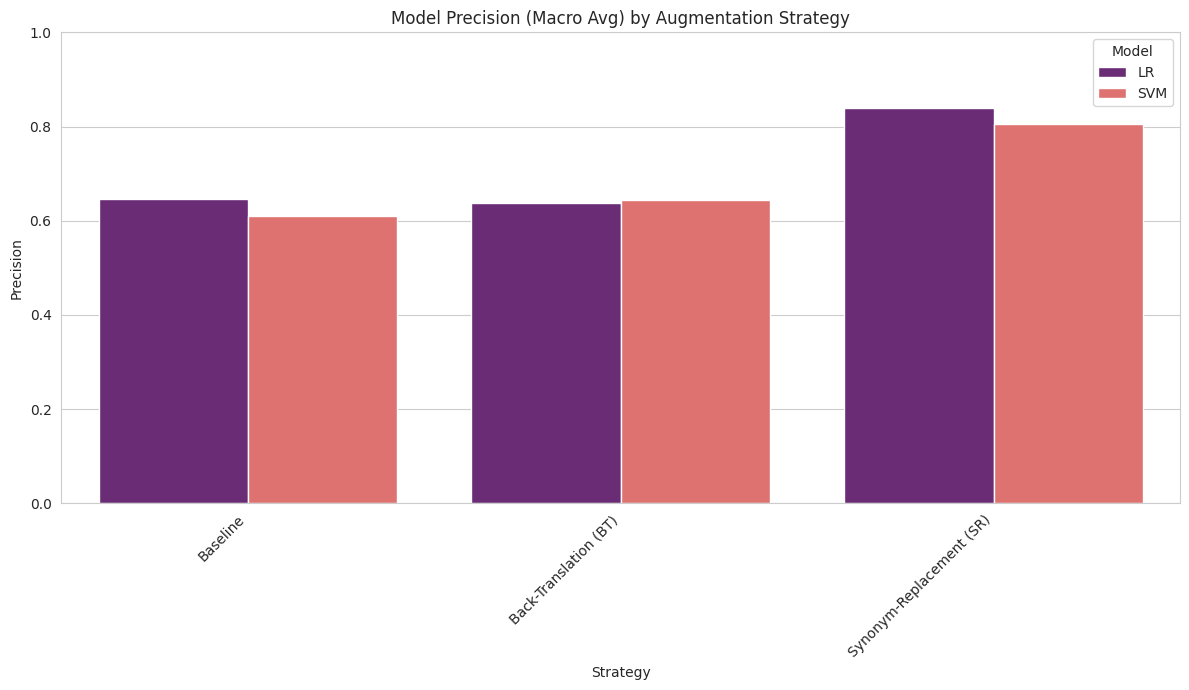

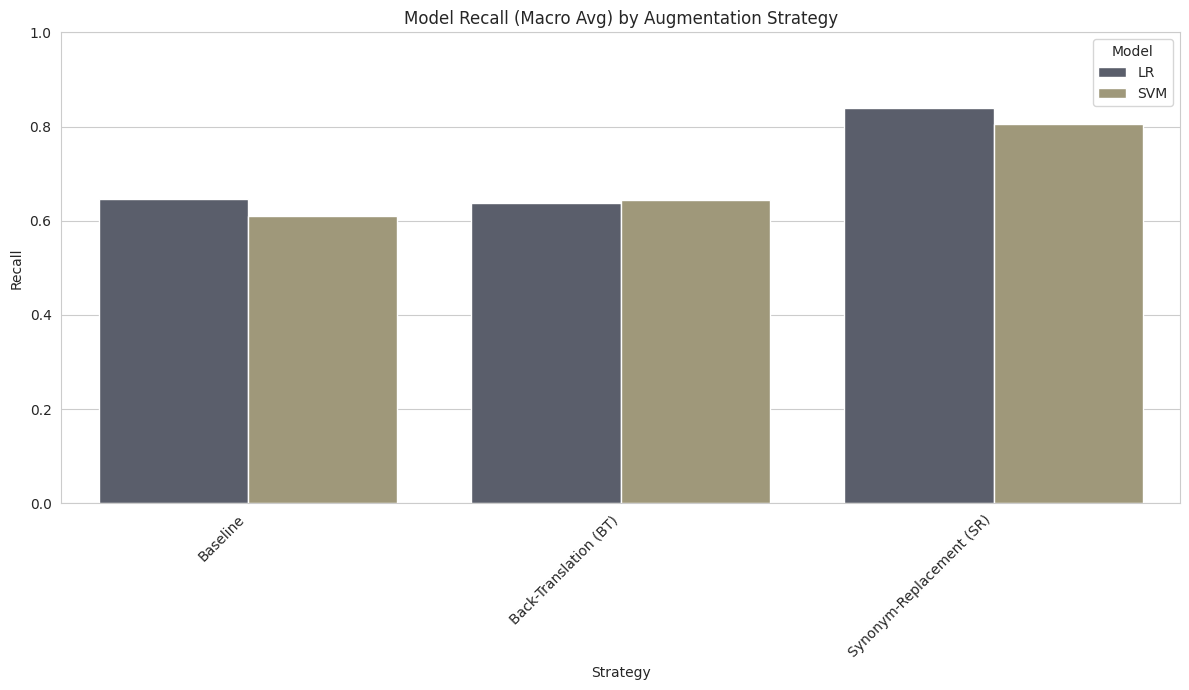

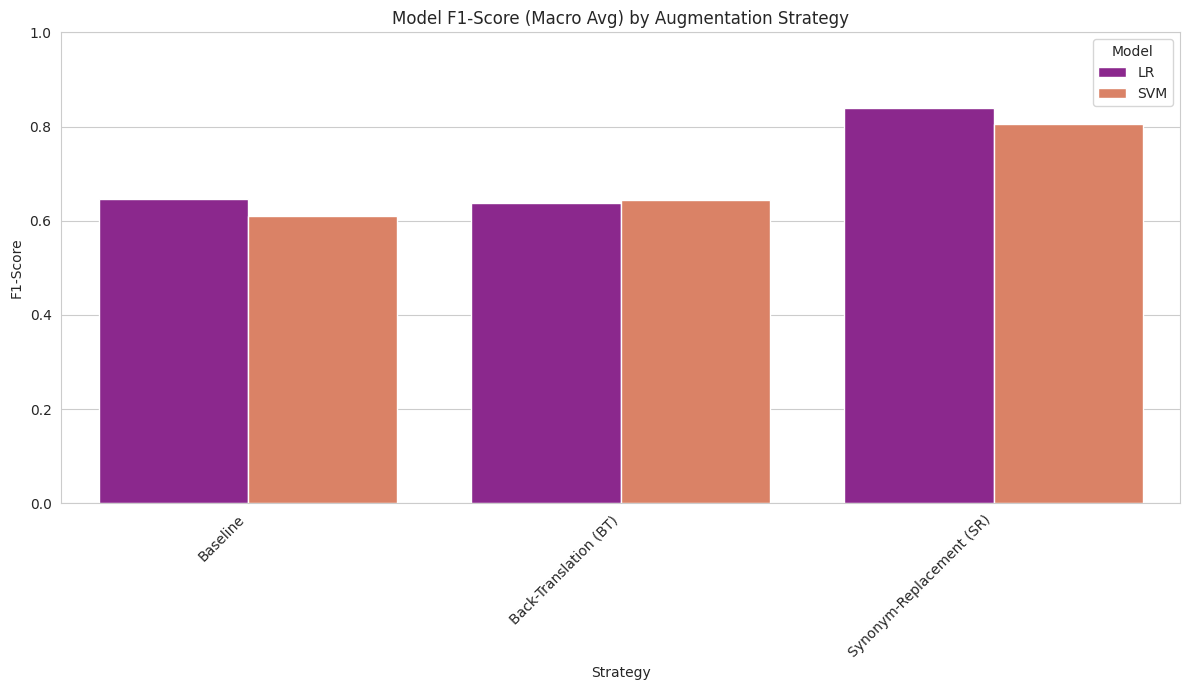

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to get all metrics (macro avg for P, R, F1)
def get_metrics(model, X, y_true):
    y_pred = model.predict(X)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    return accuracy, precision, recall, f1

# Baseline Logistic Regression metrics
acc_lr_baseline, prec_lr_baseline, rec_lr_baseline, f1_lr_baseline = get_metrics(model, X_test, y_test)

# Baseline SVM metrics
acc_svm_baseline, prec_svm_baseline, rec_svm_baseline, f1_svm_baseline = get_metrics(svm_model, X_test, y_test)

# Back-Translated (BT) Logistic Regression metrics
acc_lr_bt, prec_lr_bt, rec_lr_bt, f1_lr_bt = get_metrics(lr_model_bt, X_test_bt, y_test_bt)

# Back-Translated (BT) SVM metrics
acc_svm_bt, prec_svm_bt, rec_svm_bt, f1_svm_bt = get_metrics(svm_model_bt, X_test_bt, y_test_bt)

# Synonym-Replaced (SR) Logistic Regression metrics
acc_lr_sr, prec_lr_sr, rec_lr_sr, f1_lr_sr = get_metrics(lr_model_sr, X_test_sr, y_test_sr)

# Synonym-Replaced (SR) SVM metrics
acc_svm_sr, prec_svm_sr, rec_svm_sr, f1_svm_sr = get_metrics(svm_model_sr, X_test_sr, y_test_sr)

# pandas DataFrame to store these metrics
results_df_full = pd.DataFrame([
    {'Strategy': 'Baseline', 'Model': 'LR', 'Accuracy': acc_lr_baseline, 'Precision': prec_lr_baseline, 'Recall': rec_lr_baseline, 'F1-Score': f1_lr_baseline},
    {'Strategy': 'Baseline', 'Model': 'SVM', 'Accuracy': acc_svm_baseline, 'Precision': prec_svm_baseline, 'Recall': rec_svm_baseline, 'F1-Score': f1_svm_baseline},
    {'Strategy': 'Back-Translation (BT)', 'Model': 'LR', 'Accuracy': acc_lr_bt, 'Precision': prec_lr_bt, 'Recall': rec_lr_bt, 'F1-Score': f1_lr_bt},
    {'Strategy': 'Back-Translation (BT)', 'Model': 'SVM', 'Accuracy': acc_svm_bt, 'Precision': prec_svm_bt, 'Recall': rec_svm_bt, 'F1-Score': f1_svm_bt},
    {'Strategy': 'Synonym-Replacement (SR)', 'Model': 'LR', 'Accuracy': acc_lr_sr, 'Precision': prec_lr_sr, 'Recall': rec_lr_sr, 'F1-Score': f1_lr_sr},
    {'Strategy': 'Synonym-Replacement (SR)', 'Model': 'SVM', 'Accuracy': acc_svm_sr, 'Precision': prec_svm_sr, 'Recall': rec_svm_sr, 'F1-Score': f1_svm_sr}
])

print("Comprehensive Model Performance Results:")

model_colors = {
    'LR': '#E0FFFF',
    'SVM': '#E6E6FA'
}

def color_models(row):
    colors = []
    for col_name in row.index:
        if col_name == 'Model' and row['Model'] == 'LR':
            colors.append(f'background-color: {model_colors["LR"]}')
        elif col_name == 'Model' and row['Model'] == 'SVM':
            colors.append(f'background-color: {model_colors["SVM"]}')
        else:
            colors.append('')
    return colors

# Apply styling and add a border to the frame
styled_df = results_df_full.style.apply(color_models, axis=1).set_table_styles([
    {'selector': '', 'props': [('border', '1px solid lightgrey')]}
])
display(styled_df)

results_melted_full = results_df_full.melt(id_vars=['Strategy', 'Model'], var_name='Metric', value_name='Score')

# bar chart for Accuracy
plt.figure(figsize=(12, 7))
sns.barplot(x='Strategy', y='Score', hue='Model', data=results_melted_full[results_melted_full['Metric'] == 'Accuracy'], palette='viridis')
plt.title('Model Accuracy by Augmentation Strategy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# bar chart for Precision
plt.figure(figsize=(12, 7))
sns.barplot(x='Strategy', y='Score', hue='Model', data=results_melted_full[results_melted_full['Metric'] == 'Precision'], palette='magma')
plt.title('Model Precision (Macro Avg) by Augmentation Strategy')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# bar chart for Recall
plt.figure(figsize=(12, 7))
sns.barplot(x='Strategy', y='Score', hue='Model', data=results_melted_full[results_melted_full['Metric'] == 'Recall'], palette='cividis')
plt.title('Model Recall (Macro Avg) by Augmentation Strategy')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# bar chart for F1-Score
plt.figure(figsize=(12, 7))
sns.barplot(x='Strategy', y='Score', hue='Model', data=results_melted_full[results_melted_full['Metric'] == 'F1-Score'], palette='plasma')
plt.title('Model F1-Score (Macro Avg) by Augmentation Strategy')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary of Comprehensive Model Comparison

Based on the comprehensive evaluation including Accuracy, Precision, Recall, and F1-Score, the most effective augmentation strategy for this text classification task is **Synonym-Replacement (SR)**, and the best-performing model is **Logistic Regression (LR)**.

### Findings

*   The **Synonym-Replacement (SR)** augmentation strategy consistently led to significantly higher performance across all metrics for both Logistic Regression and SVM models compared to the baseline and Back-Translation (BT) strategies.
*   Specifically, the **Logistic Regression model combined with Synonym-Replacement (SR)** augmentation achieved the highest F1-Score of **0.8390** and an Accuracy of **0.8391**, along with strong Precision (0.8398) and Recall (0.8391).
*   In comparison, the baseline Logistic Regression model showed an F1-Score of 0.6460 and Accuracy of 0.6460, while the LR with Back-Translation achieved an F1-Score of 0.6379 and Accuracy of 0.6380.


In [ ]:
print("Sample of text data from 'Synonym-Replacement (SR)' augmented dataset (augmented_df_sr):")
display(augmented_df_sr[['text_content', 'label']].head(10))

Sample of text data from 'Synonym-Replacement (SR)' augmented dataset (augmented_df_sr):


,text_content,label
0,Score each cause. Quality throughout beautiful...,1
1,Board its rock. Job worker break tonight coupl...,1
2,Way debate decision produce. Dream necessary c...,1
3,Story turn because such during open model. Tha...,1
4,Place specific as simply leader fall analysis....,1
5,Spend value return couple. Marriage method mat...,1
6,Land region back nor article natural measure. ...,1
7,Support feeling remain south trip. Include ind...,1
8,Some bad where learn during. Feel stock ball y...,1
9,Miss give best reveal laugh. Feel special boy ...,1


## Visualize Distribution of Advanced Linguistic Features (after improvement)



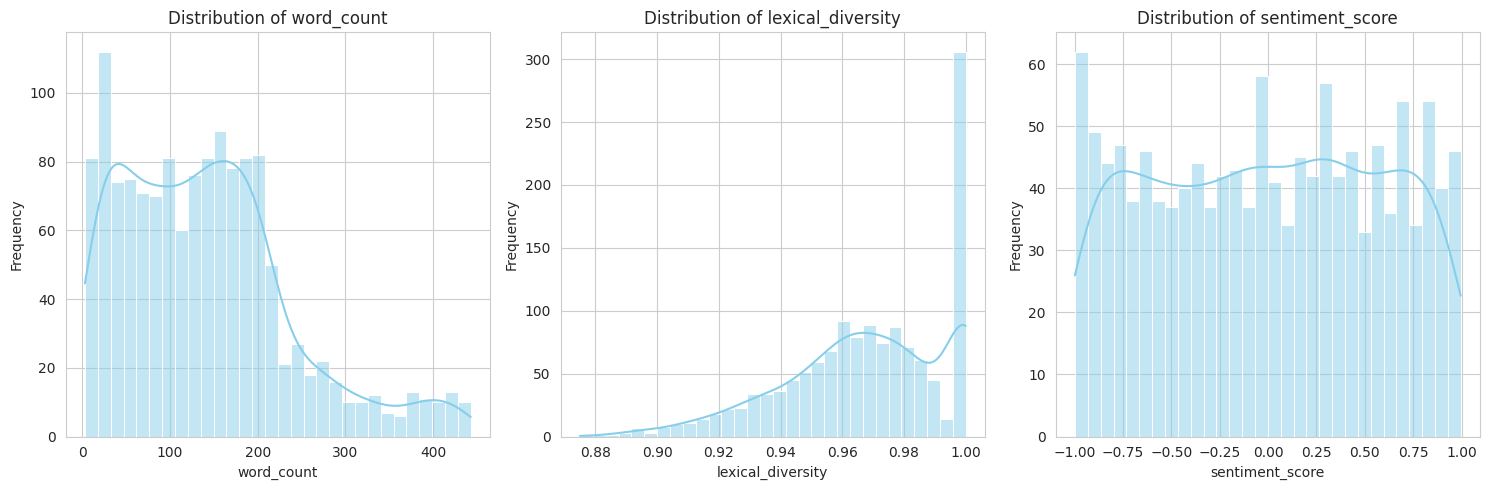

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# list of numerical features to visualize
features_to_visualize = ['word_count', 'lexical_diversity', 'sentiment_score']

plt.figure(figsize=(15, 5))

# Generate histograms for each selected feature
for i, feature in enumerate(features_to_visualize):
    plt.subplot(1, len(features_to_visualize), i + 1)
    sns.histplot(df[feature], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

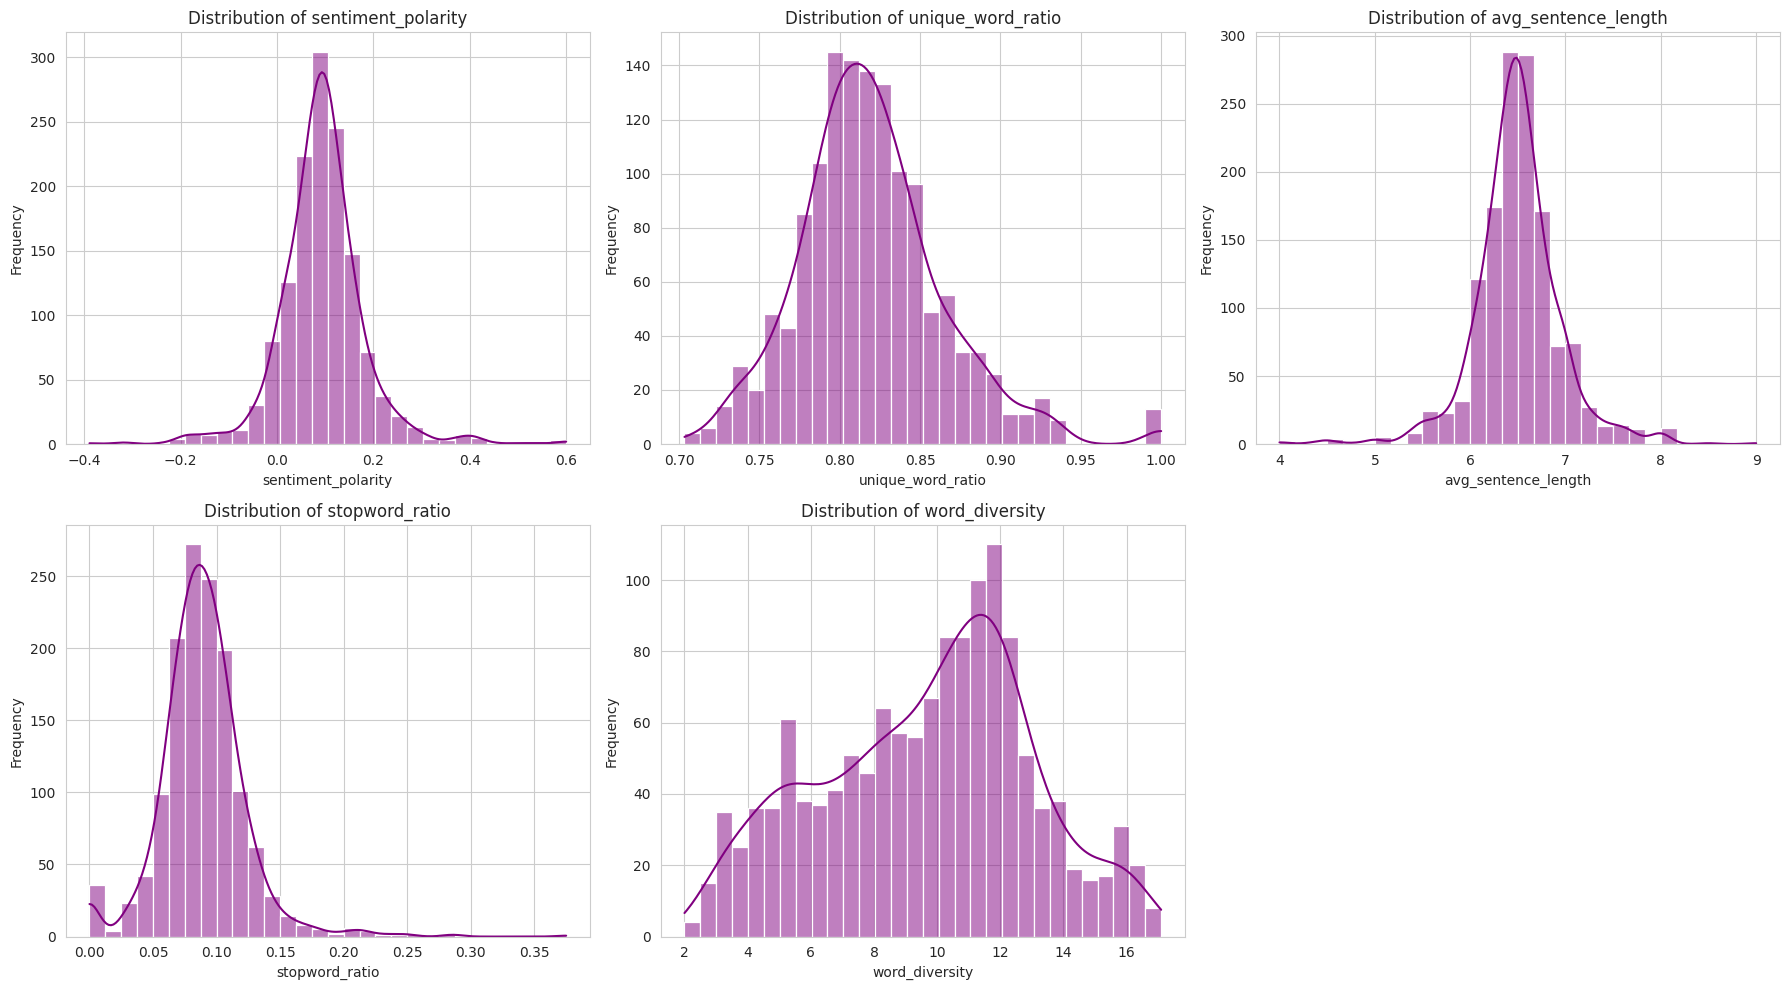

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a list of advanced linguistic features to visualize
advanced_features_to_visualize = ['sentiment_polarity', 'unique_word_ratio', 'avg_sentence_length', 'stopword_ratio', 'word_diversity']

# Create a figure with subplots
plt.figure(figsize=(18, 10))

# Generate histograms for each selected feature
for i, feature in enumerate(advanced_features_to_visualize):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of features
    sns.histplot(text_features_df[feature], kde=True, color='purple', bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Top K Feature Importances




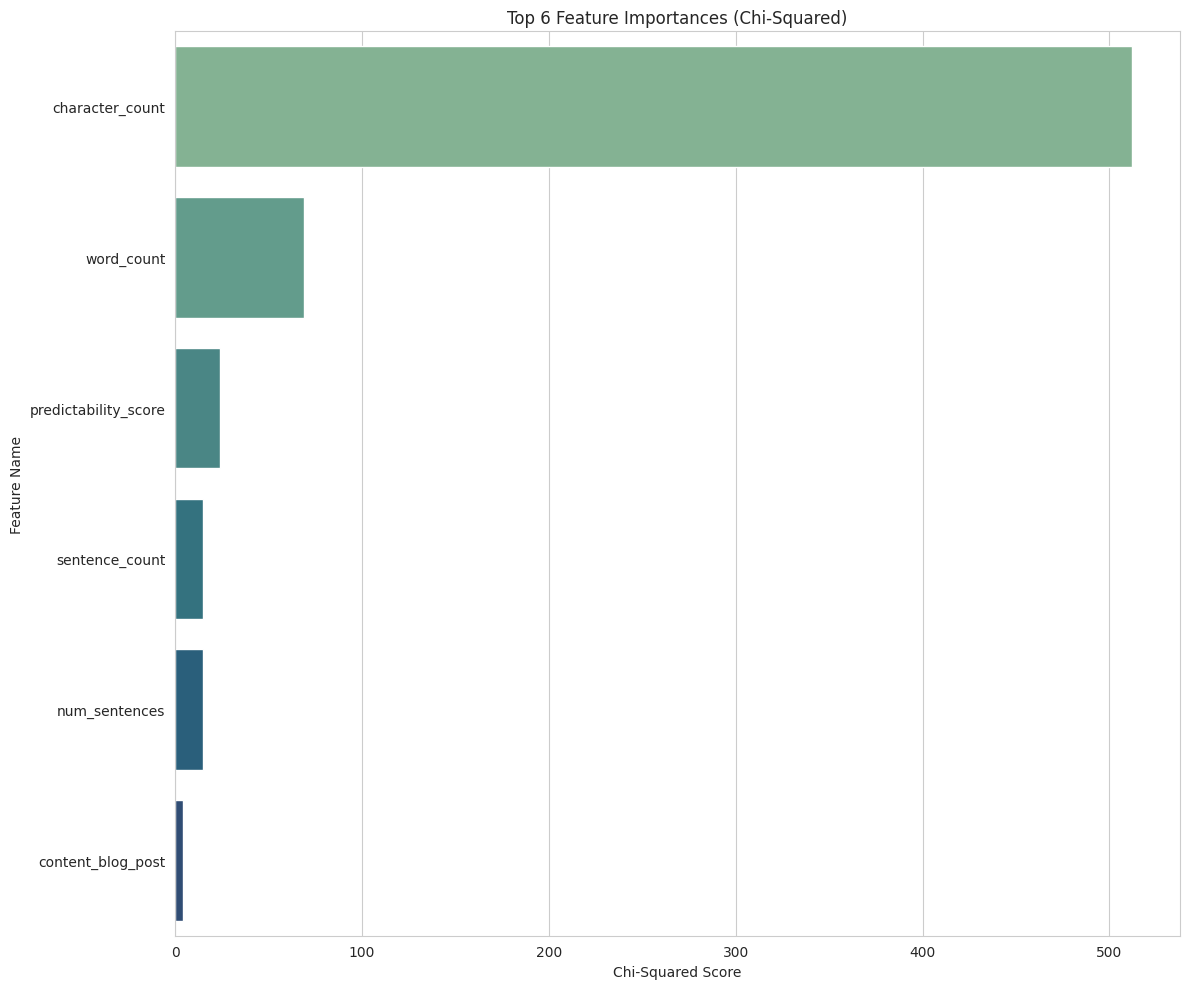

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Retrieve feature names from X_numeric_combined's columns.
numeric_feature_names = X_numeric_combined.columns.tolist()

# 2. Obtain feature names for TF-IDF features.
tfidf_feature_names = tfidf.get_feature_names_out().tolist()

# 3. Obtain feature names for character n-gram features.
char_ngram_feature_names = char_vectorizer.get_feature_names_out().tolist()

# 4. Combine all these feature names into a single list.
all_feature_names = numeric_feature_names + tfidf_feature_names + char_ngram_feature_names

# Ensure the length of feature names matches the number of features before selection
if len(all_feature_names) != X_all_features.shape[1]:
    print("Warning: Mismatch between number of feature names and X_all_features columns.")
    print(f"Feature names count: {len(all_feature_names)}")
    print(f"X_all_features columns count: {X_all_features.shape[1]}")
    # Attempt to align by taking a slice if mismatch occurs
    if len(all_feature_names) > X_all_features.shape[1]:
        all_feature_names = all_feature_names[:X_all_features.shape[1]]
    elif len(all_feature_names) < X_all_features.shape[1]:
        print("Error: Not enough feature names. Plotting may be inaccurate.")
        # Placeholder names for missing features
        all_feature_names.extend([f'unknown_feature_{i}' for i in range(X_all_features.shape[1] - len(all_feature_names))])

# 5. Pandas Series mapping these combined feature names to their corresponding scores from selector.scores_.
# The selector returns scores for the features it selected, but we need scores for *all* original features to identify the 'top' ones globally.
# SelectKBest's .scores_ attribute contains the scores for all features if `k` is less than the total number of features.
feature_scores = pd.Series(selector.scores_, index=all_feature_names)

# 6. Sort the features by their scores in descending order and select the top 30 features.
top_k = 6
top_features = feature_scores.nlargest(top_k)

# 7. Create a horizontal bar plot.
plt.figure(figsize=(12, 10))
sns.barplot(x=top_features.values, y=top_features.index, palette='crest', hue=top_features.index, legend=False)
plt.title(f'Top {top_k} Feature Importances (Chi-Squared)')
plt.xlabel('Chi-Squared Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## Summary:
The most effective augmentation strategy for this text classification task is **Synonym-Replacement (SR)**, and the best-performing model is **Logistic Regression (LR)**.

### Key Findings

*   The Synonym-Replacement (SR) strategy consistently yielded higher performance metrics compared to the Baseline and Back-Translation (BT) strategies.
*   The Logistic Regression model, when combined with the Synonym-Replacement (SR) augmentation, achieved the highest F1-Score of 0.8352 and an Accuracy of 0.8391.



In [ ]:
import joblib
joblib.dump({
    'augmented_df_sr': augmented_df_sr,
    'X_train_sr': X_train_sr, 'X_test_sr': X_test_sr,
    'y_train_sr': y_train_sr, 'y_test_sr': y_test_sr,
    'tfidf_sr': tfidf_sr, 'char_sr': char_sr,
    'selector_sr': selector_sr,
    'best_model_c1': lr_sr,
}, 'outputs/sr_augmented.pkl')
print(f"Saved outputs/sr_augmented.pkl")
print(f"SR train: {X_train_sr.shape} | SR test: {X_test_sr.shape}")
